In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess
import pyranges as pr
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

### to load a cooler with a specific resolution use the following syntax:
#### this is the binsize used for eigs
clr_rbp1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/100000")
clr_ctrl = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/100000")

import bioframe
bins = clr_ctrl.bins()[:]
hg38_genome = bioframe.load_fasta('/usr/users/papantonis1/aman/microc_project/refgen/hg38.fa');
## note the next command may require installing pysam
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_100kb.tsv',index=False,sep='\t')
display(gc_cov)

view_df_ctrl = pd.DataFrame({'chrom': clr_ctrl.chromnames,
                        'start': 0,
                        'end': clr_ctrl.chromsizes.values,
                        'name': clr_ctrl.chromnames}
                      )

view_df_rbp1 = pd.DataFrame({'chrom': clr_rbp1.chromnames,
                        'start': 0,
                        'end': clr_rbp1.chromsizes.values,
                        'name': clr_rbp1.chromnames}
                      )

# obtain first 3 eigenvectors
cis_eigs_ctrl = cooltools.eigs_cis(
                        clr_ctrl,
                        gc_cov,
                        view_df=view_df_ctrl,
                        n_eigs=3,
                        )

cis_eigs_rbp1 = cooltools.eigs_cis(
                        clr_rbp1,
                        gc_cov,
                        view_df=view_df_rbp1,
                        n_eigs=3,
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track_ctrl = cis_eigs_ctrl[1][['chrom','start','end','E1']]
eigenvector_track_rbp1 = cis_eigs_rbp1[1][['chrom','start','end','E1']]                      

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


,chrom,start,end,GC
0,chr1,0,100000,0.424522
1,chr1,100000,200000,0.458150
2,chr1,200000,300000,0.405687
3,chr1,300000,400000,0.471883
4,chr1,400000,500000,0.401920
...,...,...,...,...
30890,chrY,56900000,57000000,0.382810
30891,chrY,57000000,57100000,0.383920
30892,chrY,57100000,57200000,0.433380
30893,chrY,57200000,57227415,0.553775


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [2]:
gc_cov

,chrom,start,end,GC
0,chr1,0,100000,0.424522
1,chr1,100000,200000,0.458150
2,chr1,200000,300000,0.405687
3,chr1,300000,400000,0.471883
4,chr1,400000,500000,0.401920
...,...,...,...,...
30890,chrY,56900000,57000000,0.382810
30891,chrY,57000000,57100000,0.383920
30892,chrY,57100000,57200000,0.433380
30893,chrY,57200000,57227415,0.553775


In [3]:
# Merge E1 with GC at 100 kb and drop NaNs
ctrl_m = pd.merge(eigenvector_track_ctrl, gc_cov, on=['chrom','start','end'], how='inner')
rbp1_m = pd.merge(eigenvector_track_rbp1, gc_cov, on=['chrom','start','end'], how='inner')

print("CTRL rows:", len(ctrl_m), "  RBP1 rows:", len(rbp1_m))

# quantify missingness
print("CTRL NaNs:", ctrl_m[['E1','GC']].isna().sum().to_dict())
print("RBP1 NaNs:", rbp1_m[['E1','GC']].isna().sum().to_dict())

ctrl_m = ctrl_m.dropna(subset=['E1','GC'])
rbp1_m = rbp1_m.dropna(subset=['E1','GC'])

from scipy.stats import pearsonr
r_ctrl, _ = pearsonr(ctrl_m['E1'].values, ctrl_m['GC'].values)
r_rbp1, _ = pearsonr(rbp1_m['E1'].values, rbp1_m['GC'].values)
print(f"corr(E1,GC) 100kb  ctrl={r_ctrl:.3f}  rbp1={r_rbp1:.3f}")

CTRL rows: 30895   RBP1 rows: 30895
CTRL NaNs: {'E1': 3461, 'GC': 1384}
RBP1 NaNs: {'E1': 3358, 'GC': 1384}
corr(E1,GC) 100kb  ctrl=0.585  rbp1=0.589


In [4]:
# 1) chrom.sizes Series
chromsizes = (pd.read_csv("/usr/users/papantonis1/aman/microc_project/refgen/hg38.filtered.chrom.sizes",
                          sep="\t", header=None, names=["chrom","size"])
                .set_index("chrom")["size"])

valid_chroms = set(chromsizes.index)

# 2) keep matching chroms and handle NaNs
e1_ctrl = eigenvector_track_ctrl[eigenvector_track_ctrl["chrom"].isin(valid_chroms)].copy()
e1_rbp1 = eigenvector_track_rbp1[eigenvector_track_rbp1["chrom"].isin(valid_chroms)].copy()

# fill NaNs (bigWig doesn’t allow them)
e1_ctrl["E1"] = e1_ctrl["E1"].fillna(0.0)
e1_rbp1["E1"] = e1_rbp1["E1"].fillna(0.0)

# 3) rename 'E1' → 'value' for older bioframe API
e1_ctrl_bw  = e1_ctrl.rename(columns={"E1": "value"})
e1_rbp1_bw  = e1_rbp1.rename(columns={"E1": "value"})

# 4) write bigWigs
bf.to_bigwig(e1_ctrl_bw, chromsizes, "ctrl_eigcis_100kb.cis.bw")
bf.to_bigwig(e1_rbp1_bw, chromsizes, "rbp1_eigcis_100kb.cis.bw")

print("Wrote: ctrl_eigcis_100kb.cis.bw, rbp1_eigcis_100kb.cis.bw")


NameError: name 'bf' is not defined

In [5]:
### at 50 kb

# 1) load 50 kb coolers
clr_rbp1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/50000")
clr_ctrl = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/50000")

# 2) GC coverage at 50 kb
bins = clr_ctrl.bins()[:]
hg38_genome = bioframe.load_fasta('/usr/users/papantonis1/aman/microc_project/refgen/hg38.fa')
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_50kb.tsv', index=False, sep='\t')

# 3) view frames
view_df_ctrl = pd.DataFrame({'chrom': clr_ctrl.chromnames,
                             'start': 0,
                             'end': clr_ctrl.chromsizes.values,
                             'name': clr_ctrl.chromnames})
view_df_rbp1 = pd.DataFrame({'chrom': clr_rbp1.chromnames,
                             'start': 0,
                             'end': clr_rbp1.chromsizes.values,
                             'name': clr_rbp1.chromnames})

# 4) eigs_cis with GC phasing
cis_eigs_ctrl = cooltools.eigs_cis(clr_ctrl, gc_cov, view_df=view_df_ctrl, n_eigs=3)
cis_eigs_rbp1 = cooltools.eigs_cis(clr_rbp1, gc_cov, view_df=view_df_rbp1, n_eigs=3)

eigenvector_track_ctrl = cis_eigs_ctrl[1][['chrom','start','end','E1']]
eigenvector_track_rbp1 = cis_eigs_rbp1[1][['chrom','start','end','E1']]

# 5) sanity check correlation with GC
ctrl_m = pd.merge(eigenvector_track_ctrl, gc_cov, on=['chrom','start','end'], how='inner').dropna()
rbp1_m = pd.merge(eigenvector_track_rbp1, gc_cov, on=['chrom','start','end'], how='inner').dropna()

r_ctrl, _ = pearsonr(ctrl_m['E1'], ctrl_m['GC'])
r_rbp1, _ = pearsonr(rbp1_m['E1'], rbp1_m['GC'])
print(f"corr(E1,GC) 50kb  ctrl={r_ctrl:.3f}  rbp1={r_rbp1:.3f}")

# 6) export bigWigs
chromsizes = (pd.read_csv("/usr/users/papantonis1/aman/microc_project/refgen/hg38.filtered.chrom.sizes",
                          sep="\t", header=None, names=["chrom","size"])
                .set_index("chrom")["size"])

valid_chroms = set(chromsizes.index)
e1_ctrl = eigenvector_track_ctrl[eigenvector_track_ctrl["chrom"].isin(valid_chroms)].copy()
e1_rbp1 = eigenvector_track_rbp1[eigenvector_track_rbp1["chrom"].isin(valid_chroms)].copy()
e1_ctrl["E1"] = e1_ctrl["E1"].fillna(0.0)
e1_rbp1["E1"] = e1_rbp1["E1"].fillna(0.0)

# bioframe.to_bigwig expects column name 'value' in your version
e1_ctrl_bw = e1_ctrl.rename(columns={"E1": "value"})
e1_rbp1_bw = e1_rbp1.rename(columns={"E1": "value"})

bioframe.to_bigwig(e1_ctrl_bw, chromsizes, "ctrl_eigcis_50kb.cis.bw")
bioframe.to_bigwig(e1_rbp1_bw, chromsizes, "rbp1_eigcis_50kb.cis.bw")

print("Wrote: ctrl_eigcis_50kb.cis.bw, rbp1_eigcis_50kb.cis.bw")

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed

corr(E1,GC) 50kb  ctrl=0.551  rbp1=0.561
Wrote: ctrl_eigcis_50kb.cis.bw, rbp1_eigcis_50kb.cis.bw


In [6]:
import pandas as pd
import numpy as np

# chrom.sizes (keeps only chromosomes present there)
chromsizes = (pd.read_csv("/usr/users/papantonis1/aman/microc_project/refgen/hg38.filtered.chrom.sizes",
                          sep="\t", header=None, names=["chrom","size"])
                .set_index("chrom")["size"])
VALID = set(chromsizes.index)

def prepare_AB(e1_df):
    df = (e1_df[e1_df["chrom"].isin(VALID)]
            .dropna(subset=["E1"])
            .sort_values(["chrom","start"])
            .copy())
    # A if E1>0, B if E1<0 (zeros dropped)
    df["comp"] = np.where(df["E1"]>0, "A", np.where(df["E1"]<0, "B", np.nan))
    df = df.dropna(subset=["comp"])
    return df

def count_bins(df):
    out = df["comp"].value_counts().reindex(["A","B"]).fillna(0).astype(int)
    return {"A": int(out["A"]), "B": int(out["B"])}

def count_domains(df):
    doms = {"A":0, "B":0}
    for chrom, sub in df.groupby("chrom", sort=False):
        comps = sub["comp"].to_numpy()
        n = comps.size
        if n == 0:
            continue
        # run starts: first bin, then whenever label changes
        run_starts = np.zeros(n, dtype=bool)
        run_starts[0] = True
        if n > 1:
            run_starts[1:] = comps[1:] != comps[:-1]
        run_labels = comps[run_starts]
        u, c = np.unique(run_labels, return_counts=True)
        for lab, cnt in zip(u, c):
            doms[lab] += int(cnt)
    return doms

def summarize(name, e1_df):
    df = prepare_AB(e1_df)
    bins = count_bins(df)
    doms = count_domains(df)
    total = bins["A"] + bins["B"]
    print(f"{name}")
    print(f"  bins:    A={bins['A']:,}  B={bins['B']:,}  (total {total:,})")
    print(f"  domains: A={doms['A']:,}  B={doms['B']:,}")
    if total:
        print(f"  fraction A={bins['A']/total:.3f}  B={bins['B']/total:.3f}")
    print("")

# ---- run (100 kb tracks from your notebook) ----
summarize("CTRL 100kb", eigenvector_track_ctrl)
summarize("RBP1 100kb", eigenvector_track_rbp1)

# ---- run for 50 kb if you have them as eigenvector_track_ctrl_50 / _rbp1_50 ----
try:
    summarize("CTRL 50kb", eigenvector_track_ctrl_50)
    summarize("RBP1 50kb", eigenvector_track_rbp1_50)
except NameError:
    pass

CTRL 100kb
  bins:    A=26,045  B=28,659  (total 54,704)
  domains: A=1,557  B=1,544
  fraction A=0.476  B=0.524

RBP1 100kb
  bins:    A=27,499  B=27,472  (total 54,971)
  domains: A=1,603  B=1,592
  fraction A=0.500  B=0.500



/tmp/ipykernel_654508/1092235585.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom", sort=False):
/tmp/ipykernel_654508/1092235585.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom", sort=False):


In [7]:
def per_chrom_bins(e1_df, chromsizes):
    d = (e1_df[e1_df.chrom.isin(chromsizes.index)]
           .dropna(subset=["E1"]).copy())
    d["comp"] = np.where(d["E1"]>0, "A", "B")
    out = (d.groupby("chrom")["comp"]
             .value_counts()
             .unstack(fill_value=0)
             .reindex(columns=["A","B"], fill_value=0))
    out["total"] = out["A"] + out["B"]
    out["fracA"] = out["A"] / out["total"].replace(0, np.nan)
    return out

per_chr_ctrl = per_chrom_bins(eigenvector_track_ctrl, chromsizes)
per_chr_rbp1 = per_chrom_bins(eigenvector_track_rbp1, chromsizes)
delta = (per_chr_rbp1["fracA"] - per_chr_ctrl["fracA"]).to_frame("Δ fracA (RBP1-CTRL)").sort_values("Δ fracA (RBP1-CTRL)")
print(delta)

       Δ fracA (RBP1-CTRL)
chrom                     
chr19             0.002157
chr12             0.007520
chr21             0.008201
chr1              0.010528
chr3              0.015906
chr14             0.017198
chr9              0.017276
chr20             0.017915
chr17             0.019994
chr11             0.021327
chr7              0.021376
chrX              0.022141
chr2              0.022418
chr10             0.023736
chr6              0.024913
chr16             0.025447
chr4              0.026649
chr8              0.027447
chr18             0.029487
chr15             0.032780
chr13             0.033837
chr5              0.034597
chrY              0.034739
chr22             0.216145
chrM                   NaN


/tmp/ipykernel_654508/2666572684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (d.groupby("chrom")["comp"]
/tmp/ipykernel_654508/2666572684.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (d.groupby("chrom")["comp"]


In [8]:
chromsizes = (pd.read_csv("/usr/users/papantonis1/aman/microc_project/refgen/hg38.filtered.chrom.sizes",
                          sep="\t", header=None, names=["chrom","size"])
                .set_index("chrom")["size"])
VALID = set(chromsizes.index)

def prepare_AB(e1_df):
    df = (e1_df[e1_df["chrom"].isin(VALID)]
            .dropna(subset=["E1"])
            .sort_values(["chrom","start"])
            .copy())
    df["comp"] = np.where(df["E1"]>0, "A", np.where(df["E1"]<0, "B", np.nan))
    df = df.dropna(subset=["comp"])
    return df

def count_bins(df):
    out = df["comp"].value_counts().reindex(["A","B"]).fillna(0).astype(int)
    return {"A": int(out["A"]), "B": int(out["B"])}

def count_domains(df):
    doms = {"A":0, "B":0}
    for chrom, sub in df.groupby("chrom", sort=False):
        comps = sub["comp"].to_numpy()
        n = comps.size
        if n == 0: 
            continue
        run_starts = np.zeros(n, dtype=bool)
        run_starts[0] = True
        if n > 1:
            run_starts[1:] = comps[1:] != comps[:-1]
        for lab, cnt in zip(*np.unique(comps[run_starts], return_counts=True)):
            doms[lab] += int(cnt)
    return doms

def summarize(name, e1_df):
    df = prepare_AB(e1_df)
    bins = count_bins(df)
    doms = count_domains(df)
    total = bins["A"] + bins["B"]
    print(f"{name}")
    print(f"  bins:    A={bins['A']:,}  B={bins['B']:,}  (total {total:,})")
    print(f"  domains: A={doms['A']:,}  B={doms['B']:,}")
    if total:
        print(f"  fraction A={bins['A']/total:.3f}  B={bins['B']/total:.3f}")
    print("")

# ---------- ensure we have 50 kb E1 (GC‑phased) ----------
try:
    eigenvector_track_ctrl_50
    eigenvector_track_rbp1_50
except NameError:
    clr_ctrl_50 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/50000")
    clr_rbp1_50 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/50000")

    bins50 = clr_ctrl_50.bins()[:]
    fasta = bioframe.load_fasta("/usr/users/papantonis1/aman/microc_project/refgen/hg38.fa")
    gc50 = bioframe.frac_gc(bins50[['chrom','start','end']], fasta)

    view_ctrl_50 = pd.DataFrame({'chrom': clr_ctrl_50.chromnames, 'start': 0,
                                 'end': clr_ctrl_50.chromsizes.values, 'name': clr_ctrl_50.chromnames})
    view_rbp1_50 = pd.DataFrame({'chrom': clr_rbp1_50.chromnames, 'start': 0,
                                 'end': clr_rbp1_50.chromsizes.values, 'name': clr_rbp1_50.chromnames})

    eigs_c50 = cooltools.eigs_cis(clr_ctrl_50, gc50, view_df=view_ctrl_50, n_eigs=3)
    eigs_r50 = cooltools.eigs_cis(clr_rbp1_50, gc50, view_df=view_rbp1_50, n_eigs=3)

    eigenvector_track_ctrl_50 = eigs_c50[1][['chrom','start','end','E1']]
    eigenvector_track_rbp1_50 = eigs_r50[1][['chrom','start','end','E1']]

    # sanity: positive corr with GC → correct phasing
    mC = pd.merge(eigenvector_track_ctrl_50, gc50, on=['chrom','start','end']).dropna()
    mR = pd.merge(eigenvector_track_rbp1_50, gc50, on=['chrom','start','end']).dropna()
    rc,_ = pearsonr(mC['E1'], mC.iloc[:,3])   # gc column name may be 'GC' or 'frac_gc'
    rr,_ = pearsonr(mR['E1'], mR.iloc[:,3])
    if rc < 0: eigenvector_track_ctrl_50['E1'] *= -1
    if rr < 0: eigenvector_track_rbp1_50['E1'] *= -1

# ---------- 50 kb A/B counts ----------
summarize("CTRL 50kb", eigenvector_track_ctrl_50)
summarize("RBP1 50kb", eigenvector_track_rbp1_50)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


CTRL 50kb
  bins:    A=26,045  B=28,659  (total 54,704)
  domains: A=1,557  B=1,544
  fraction A=0.476  B=0.524

RBP1 50kb
  bins:    A=27,499  B=27,472  (total 54,971)
  domains: A=1,603  B=1,592
  fraction A=0.500  B=0.500



/tmp/ipykernel_654508/1801745076.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom", sort=False):
/tmp/ipykernel_654508/1801745076.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom", sort=False):


/tmp/ipykernel_654508/685689592.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


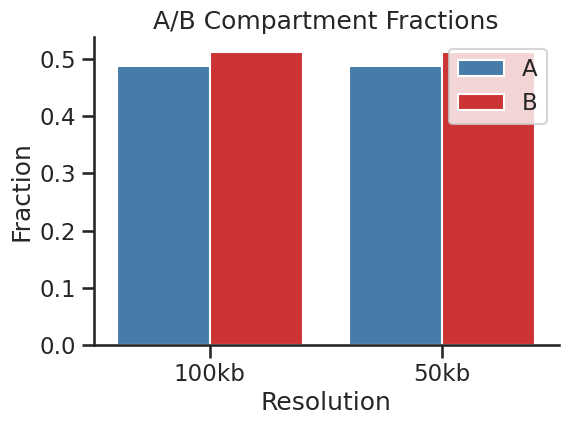

In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# --- tidy DataFrame for fractions ---
data_frac = pd.DataFrame({
    "Condition": ["CTRL", "RBP1", "CTRL", "RBP1"],
    "Resolution": ["100kb", "100kb", "50kb", "50kb"],
    "A_fraction": [0.476, 0.500, 0.476, 0.500],
    "B_fraction": [0.524, 0.500, 0.524, 0.500],
})

# melt to long form for plotting
df_frac = data_frac.melt(
    id_vars=["Condition","Resolution"],
    value_vars=["A_fraction","B_fraction"],
    var_name="Compartment",
    value_name="Fraction"
)
df_frac["Compartment"] = df_frac["Compartment"].str.replace("_fraction","")

# --- seaborn style ---
sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df_frac, x="Resolution", y="Fraction", hue="Compartment",
    hue_order=["A","B"], ci=None, palette=["#377eb8","#e41a1c"]
)
sns.despine()
ax.set_title("A/B Compartment Fractions")
plt.legend(title="")
plt.show()

/tmp/ipykernel_654508/2865042271.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


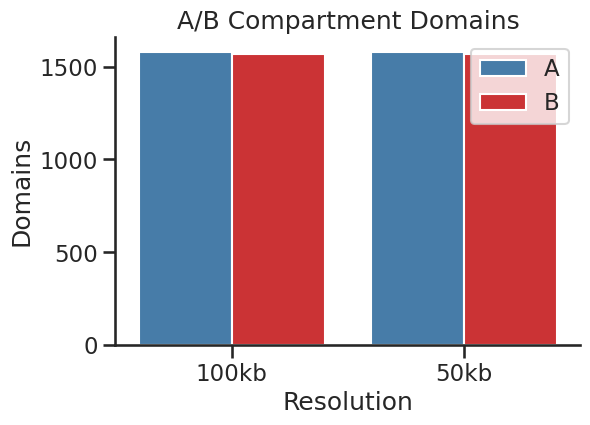

In [10]:
# --- tidy DataFrame for domains ---
data_dom = pd.DataFrame({
    "Condition": ["CTRL","RBP1","CTRL","RBP1"],
    "Resolution": ["100kb","100kb","50kb","50kb"],
    "A_domains": [1557,1603,1557,1603],
    "B_domains": [1544,1592,1544,1592],
})

df_dom = data_dom.melt(
    id_vars=["Condition","Resolution"],
    value_vars=["A_domains","B_domains"],
    var_name="Compartment",
    value_name="Domains"
)
df_dom["Compartment"] = df_dom["Compartment"].str.replace("_domains","")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df_dom, x="Resolution", y="Domains", hue="Compartment",
    hue_order=["A","B"], ci=None, palette=["#377eb8","#e41a1c"]
)
sns.despine()
ax.set_title("A/B Compartment Domains")
plt.legend(title="")
plt.show()

/tmp/ipykernel_654508/2424673783.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


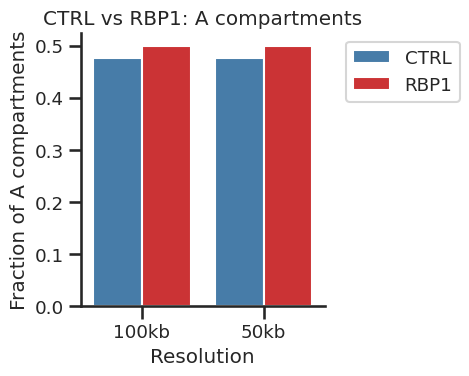

/tmp/ipykernel_654508/2424673783.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


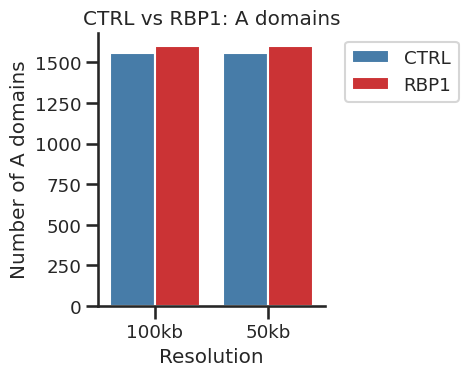

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.8)

# Fractions of A
df_A_frac = pd.DataFrame({
    "Condition": ["CTRL","RBP1","CTRL","RBP1"],
    "Resolution": ["100kb","100kb","50kb","50kb"],
    "Fraction": [0.476, 0.500, 0.476, 0.500],
})

plt.figure(figsize=(5,4))
ax = sns.barplot(
    data=df_A_frac, x="Resolution", y="Fraction", hue="Condition",
    palette=["#377eb8","#e41a1c"], ci=None
)
sns.despine()
ax.set_ylabel("Fraction of A compartments")
ax.set_title("CTRL vs RBP1: A compartments")
ax.legend(title="", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# Domains of A
df_A_dom = pd.DataFrame({
    "Condition": ["CTRL","RBP1","CTRL","RBP1"],
    "Resolution": ["100kb","100kb","50kb","50kb"],
    "Domains": [1557,1603,1557,1603],
})

plt.figure(figsize=(5,4))
ax = sns.barplot(
    data=df_A_dom, x="Resolution", y="Domains", hue="Condition",
    palette=["#377eb8","#e41a1c"], ci=None
)
sns.despine()
ax.set_ylabel("Number of A domains")
ax.set_title("CTRL vs RBP1: A domains")
ax.legend(title="", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_654508/2876063677.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


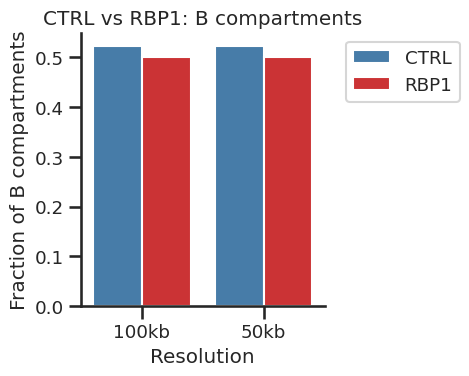

/tmp/ipykernel_654508/2876063677.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


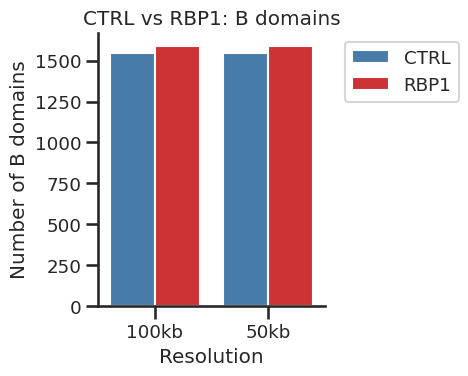

In [12]:
# Fractions of B
df_B_frac = pd.DataFrame({
    "Condition": ["CTRL","RBP1","CTRL","RBP1"],
    "Resolution": ["100kb","100kb","50kb","50kb"],
    "Fraction": [0.524, 0.500, 0.524, 0.500],
})

plt.figure(figsize=(5,4))
ax = sns.barplot(
    data=df_B_frac, x="Resolution", y="Fraction", hue="Condition",
    palette=["#377eb8","#e41a1c"], ci=None
)
sns.despine()
ax.set_ylabel("Fraction of B compartments")
ax.set_title("CTRL vs RBP1: B compartments")
ax.legend(title="", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# Domains of B
df_B_dom = pd.DataFrame({
    "Condition": ["CTRL","RBP1","CTRL","RBP1"],
    "Resolution": ["100kb","100kb","50kb","50kb"],
    "Domains": [1544,1592,1544,1592],
})

plt.figure(figsize=(5,4))
ax = sns.barplot(
    data=df_B_dom, x="Resolution", y="Domains", hue="Condition",
    palette=["#377eb8","#e41a1c"], ci=None
)
sns.despine()
ax.set_ylabel("Number of B domains")
ax.set_title("CTRL vs RBP1: B domains")
ax.legend(title="", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_654508/611080941.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom"):
/tmp/ipykernel_654508/611080941.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom"):
/tmp/ipykernel_654508/611080941.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chrom, sub in df.groupby("chrom"):
/tmp/ipykernel_654508/611080941.py:23: FutureWarning

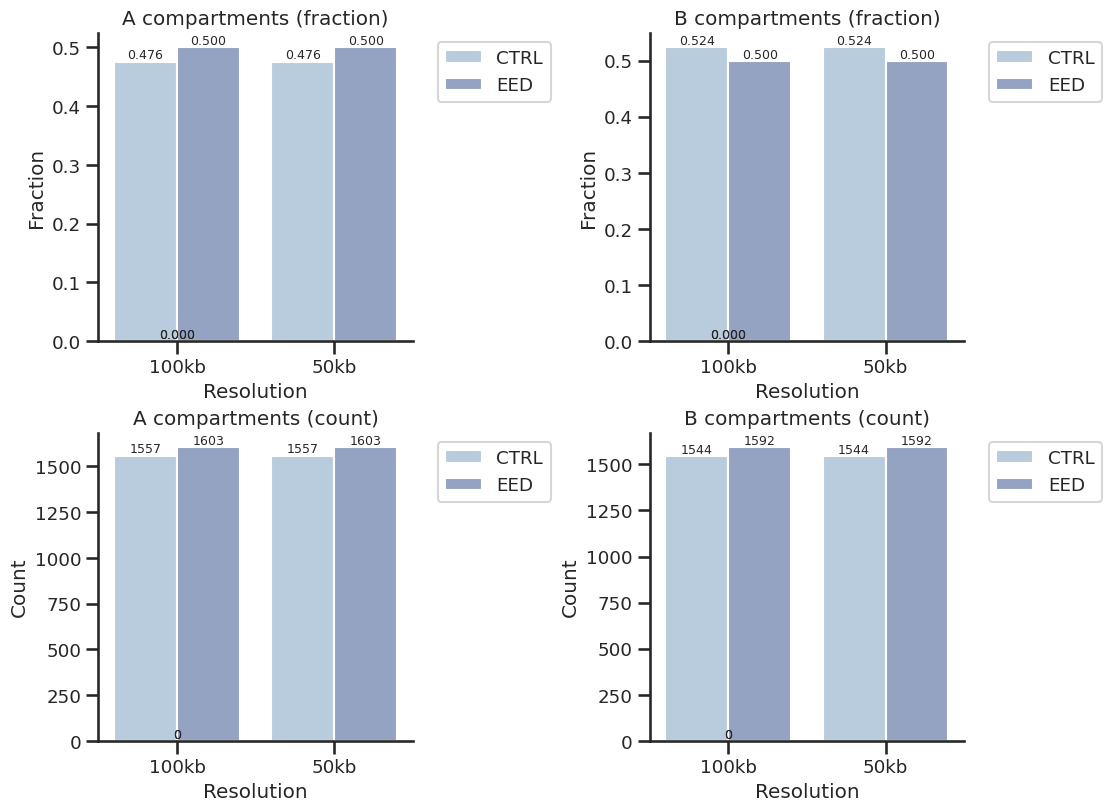

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === classify bins into A/B ===
def classify_compartments(e1_df, chromsizes):
    df = (e1_df[e1_df["chrom"].isin(chromsizes.index)]
            .dropna(subset=["E1"])
            .copy())
    df["comp"] = np.where(df["E1"] > 0, "A", "B")
    return df

# === compute fractions and domains ===
def compartment_summary(name, e1_df, chromsizes):
    df = classify_compartments(e1_df, chromsizes)

    # bin fractions
    frac = df["comp"].value_counts(normalize=True)

    # domain counts
    dom_counts = {"A":0,"B":0}
    for chrom, sub in df.groupby("chrom"):
        comps = sub.sort_values("start")["comp"].to_numpy()
        if len(comps) == 0: 
            continue
        runs = np.r_[True, comps[1:] != comps[:-1]]
        run_labels = comps[runs]
        for lab in run_labels:
            dom_counts[lab] += 1

    return {
        "Condition": name.split()[0],
        "Resolution": name.split()[1],
        "A_fraction": frac.get("A",0),
        "B_fraction": frac.get("B",0),
        "A_domains": dom_counts["A"],
        "B_domains": dom_counts["B"]
    }

# === collect summaries ===
summaries = [
    compartment_summary("CTRL 100kb", eigenvector_track_ctrl, chromsizes),
    compartment_summary("EED 100kb", eigenvector_track_rbp1, chromsizes),
    compartment_summary("CTRL 50kb",  eigenvector_track_ctrl_50, chromsizes),
    compartment_summary("EED 50kb",  eigenvector_track_rbp1_50, chromsizes),
]
df_summary = pd.DataFrame(summaries)

# === reshape for plotting ===
df_frac = df_summary.melt(id_vars=["Condition","Resolution"],
                          value_vars=["A_fraction","B_fraction"],
                          var_name="Compartment", value_name="Fraction")
df_frac["Compartment"] = df_frac["Compartment"].str.replace("_fraction","")

df_dom = df_summary.melt(id_vars=["Condition","Resolution"],
                         value_vars=["A_domains","B_domains"],
                         var_name="Compartment", value_name="Count")  # changed Domains→Count
df_dom["Compartment"] = df_dom["Compartment"].str.replace("_domains","")

# === plotting ===
custom_palette = ["#b3cde3","#8da0cb"]

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.8)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

def annotate_bars(ax, fmt="{:.3f}"):
    for p in ax.patches:
        value = p.get_height()
        ax.annotate(fmt.format(value),
                    (p.get_x() + p.get_width() / 2., value),
                    ha='center', va='bottom', fontsize=9, rotation=0)

# Fractions
ax0 = sns.barplot(data=df_frac[df_frac["Compartment"]=="A"], x="Resolution", y="Fraction",
                  hue="Condition", palette=custom_palette, ax=axes[0,0])
axes[0,0].set_title("A compartments (fraction)")
axes[0,0].legend(bbox_to_anchor=(1.05,1), loc="upper left")
annotate_bars(ax0, fmt="{:.3f}")

ax1 = sns.barplot(data=df_frac[df_frac["Compartment"]=="B"], x="Resolution", y="Fraction",
                  hue="Condition", palette=custom_palette, ax=axes[0,1])
axes[0,1].set_title("B compartments (fraction)")
axes[0,1].legend(bbox_to_anchor=(1.05,1), loc="upper left")
annotate_bars(ax1, fmt="{:.3f}")

# Domains → Counts
ax2 = sns.barplot(data=df_dom[df_dom["Compartment"]=="A"], x="Resolution", y="Count",
                  hue="Condition", palette=custom_palette, ax=axes[1,0])
axes[1,0].set_title("A compartments (count)")
axes[1,0].legend(bbox_to_anchor=(1.05,1), loc="upper left")
annotate_bars(ax2, fmt="{:.0f}")

ax3 = sns.barplot(data=df_dom[df_dom["Compartment"]=="B"], x="Resolution", y="Count",
                  hue="Condition", palette=custom_palette, ax=axes[1,1])
axes[1,1].set_title("B compartments (count)")
axes[1,1].legend(bbox_to_anchor=(1.05,1), loc="upper left")
annotate_bars(ax3, fmt="{:.0f}")

plt.show()